In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [3]:
path = '/content/drive/MyDrive/SKRIPSI/fixed_final_dataset.csv'
df = pd.read_csv(path, delimiter=',')

df.head()

,created_at,full_text_processed,label
0,06/04/2025,anybodi need chip insert brain name fafo satan...,0
1,06/04/2025,pledg support justic digniti peac gaza join st...,0
2,06/04/2025,take posit gaza take posit gaza one live rest ...,0
3,06/04/2025,children gaza stand proof world look away dont...,0
4,06/04/2025,donat famili gaza struggl surviv war everi lit...,0


In [4]:
# Inisialisasi TF-IDF
vectorizer = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
)

X = vectorizer.fit_transform(df["full_text_processed"])
y = df["label"].values


In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

NAIVE BAYES


In [7]:
# cross validation + gridsearch

X_train, X_test, y_train, y_test = train_test_split(
    df["full_text_processed"].astype(str),
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


pipeline_nb = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

param_grid_nb = {
    "tfidf__max_features": [2000, 3000, 4000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__norm": ["l1", "l2"],
    "nb__alpha": [0.1, 0.5, 1.0],
    "nb__fit_prior": [True, False],
}

grid_nb = GridSearchCV(
    pipeline_nb,
    param_grid_nb,
    cv=10,
    n_jobs=-1,
    scoring="f1_macro",
    verbose=2
)

grid_nb.fit(X_train, y_train)

print("\n=== Best Parameters ===")
print(grid_nb.best_params_)

print("\n=== Best CV F1-Macro Score ===")
print(grid_nb.best_score_)

best_model = grid_nb.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== Final Evaluation on Test Set ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-Macro:", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 10 folds for each of 72 candidates, totalling 720 fits

=== Best Parameters ===
{'nb__alpha': 0.1, 'nb__fit_prior': True, 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l1'}

=== Best CV F1-Macro Score ===
0.7906798658839881

=== Final Evaluation on Test Set ===
Accuracy: 0.7921052631578948
F1-Macro: 0.7930820671818681

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.78      0.74       127
           1       0.91      0.87      0.89       128
           2       0.78      0.73      0.76       125

    accuracy                           0.79       380
   macro avg       0.80      0.79      0.79       380
weighted avg       0.80      0.79      0.79       380



In [8]:
import pandas as pd

print("=== Best Parameters ===")
print(grid_nb.best_params_)

print("\n=== Best F1-Macro Score ===")
print(grid_nb.best_score_)

print("\n=== Full Results ===")

results = pd.DataFrame(grid_nb.cv_results_)

cols = [
    "params",
    "mean_test_score",
    "std_test_score",
    "mean_fit_time",
    "rank_test_score"
]

df_results = results[cols].sort_values(by="mean_test_score", ascending=False)

# Tampilkan semua
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

print(df_results)


=== Best Parameters ===
{'nb__alpha': 0.1, 'nb__fit_prior': True, 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l1'}

=== Best F1-Macro Score ===
0.7906798658839881

=== Full Results ===
                                                                                                                        params  \
10   {'nb__alpha': 0.1, 'nb__fit_prior': True, 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l1'}   
22  {'nb__alpha': 0.1, 'nb__fit_prior': False, 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l1'}   
23  {'nb__alpha': 0.1, 'nb__fit_prior': False, 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2'}   
11   {'nb__alpha': 0.1, 'nb__fit_prior': True, 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2'}   
6    {'nb__alpha': 0.1, 'nb__fit_prior': True, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l1'}   
18  

In [11]:
# CV fold=10 (model training)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

fold = 1
for train_idx, val_idx in skf.split(df["full_text_processed"], df["label"]):

    X_train_cv = df["full_text_processed"].iloc[train_idx].astype(str)
    X_val_cv   = df["full_text_processed"].iloc[val_idx].astype(str)
    y_train_cv = df["label"].iloc[train_idx]
    y_val_cv   = df["label"].iloc[val_idx]

    # TF-IDF (best params)
    tfidf = TfidfVectorizer(
        max_features=4000,
        ngram_range=(1,2),
        norm="l1"
    )

    X_train_tfidf = tfidf.fit_transform(X_train_cv)
    X_val_tfidf   = tfidf.transform(X_val_cv)

    # Naive Bayes (best params)
    nb = MultinomialNB(alpha=0.1, fit_prior=False)
    nb.fit(X_train_tfidf, y_train_cv)

    # Prediction
    y_pred_cv = nb.predict(X_val_tfidf)

    # Evaluation (convert to %)
    acc = accuracy_score(y_val_cv, y_pred_cv) * 100
    prec = precision_score(y_val_cv, y_pred_cv, average="macro") * 100
    rec = recall_score(y_val_cv, y_pred_cv, average="macro") * 100
    f1 = f1_score(y_val_cv, y_pred_cv, average="macro") * 100

    results.append({
        "Fold": fold,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,

    })

    fold += 1

# Convert to DataFrame
df_cv_results = pd.DataFrame(results).round(2)

print("=== 10-Fold Cross Validation Results (Naive Bayes) ===")
print(df_cv_results)

print("\n=== Rata-rata Performa ===")
print(df_cv_results.mean(numeric_only=True).round(2))


=== 10-Fold Cross Validation Results (Naive Bayes) ===
   Fold  Accuracy  F1-Score  Precision  Recall
0     1     81.05     81.08      81.57   81.03
1     2     77.37     77.59      78.66   77.34
2     3     76.32     76.55      78.13   76.23
3     4     80.53     80.79      81.66   80.54
4     5     78.42     78.79      79.79   78.40
5     6     83.16     83.34      84.11   83.16
6     7     78.31     78.30      79.59   78.27
7     8     75.66     75.97      76.86   75.63
8     9     77.78     78.00      78.51   77.70
9    10     80.42     80.53      81.00   80.44

=== Rata-rata Performa ===
Fold          5.50
Accuracy     78.90
F1-Score     79.09
Precision    79.99
Recall       78.87
dtype: float64


In [12]:
# report model (test mode)
X_text = df["full_text_processed"].astype(str)
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


tfidf_final = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
    norm="l1"
)

X_train_tfidf = tfidf_final.fit_transform(X_train_text)
X_test_tfidf  = tfidf_final.transform(X_test_text)

nb_final = MultinomialNB(alpha=0.1, fit_prior=False)
nb_final.fit(X_train_tfidf, y_train)

y_pred_test = nb_final.predict(X_test_tfidf)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.70      0.78      0.74       127
           1       0.91      0.85      0.88       128
           2       0.78      0.74      0.76       125

    accuracy                           0.79       380
   macro avg       0.80      0.79      0.79       380
weighted avg       0.80      0.79      0.79       380



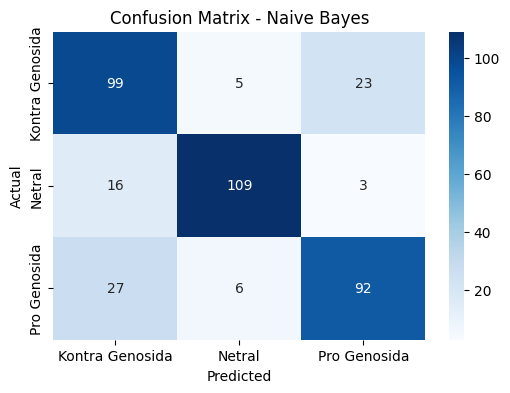

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
class_labels = ["Kontra Genosida", "Netral", "Pro Genosida"]

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
    yticklabels=class_labels)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [14]:
def predict_sentiment_nb(text, nb_model, vectorizer):
    text_vec = vectorizer.transform([text])

    pred_proba = nb_model.predict_proba(text_vec)[0]
    label = nb_model.predict(text_vec)[0]

    label_map = {
        0: "Kontra-Genocide",
        1: "Netral",
        2: "Pro-Genocide"
    }

    print(f"\nTeks: {text}")
    print(f"Prediksi: {label_map[label]} (label : {label})")
    print(f"Probabilitas: {pred_proba}")

    return label_map[label]


In [15]:
contoh_text = [
    "Israel is preventing humanitarian aid from entering Gaza, worsening the humanitarian crisis.",
    "Schools in Gaza have been destroyed, leaving young people already deprived of education due to COVID-19 and war, and facing a loss of future opportunities.",
    "Three Israeli hostages were handed over by Hamas in Gaza, while Palestinian prisoners were released as part of a ceasefire deal.",
    "A Chicago-based surgeon has treated patients with war-related injuries from Syria, Ukraine, and Gaza.",
    "Supporting Israel is described as supporting humanity, while opposing Hamas terrorism is also framed as a defense of human values.",
    "Hamas is the true terrorist."
]

for t in contoh_text:
    predict_sentiment_nb(t, nb_final, tfidf_final)


Teks: Israel is preventing humanitarian aid from entering Gaza, worsening the humanitarian crisis.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.63633504 0.16054358 0.20312138]

Teks: Schools in Gaza have been destroyed, leaving young people already deprived of education due to COVID-19 and war, and facing a loss of future opportunities.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.4630857  0.23931988 0.29759442]

Teks: Three Israeli hostages were handed over by Hamas in Gaza, while Palestinian prisoners were released as part of a ceasefire deal.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.39837504 0.37484489 0.22678007]

Teks: A Chicago-based surgeon has treated patients with war-related injuries from Syria, Ukraine, and Gaza.
Prediksi: Netral (label : 1)
Probabilitas: [0.36252596 0.37473065 0.26274339]

Teks: Supporting Israel is described as supporting humanity, while opposing Hamas terrorism is also framed as a defense of human values.
Prediksi: Pro-G

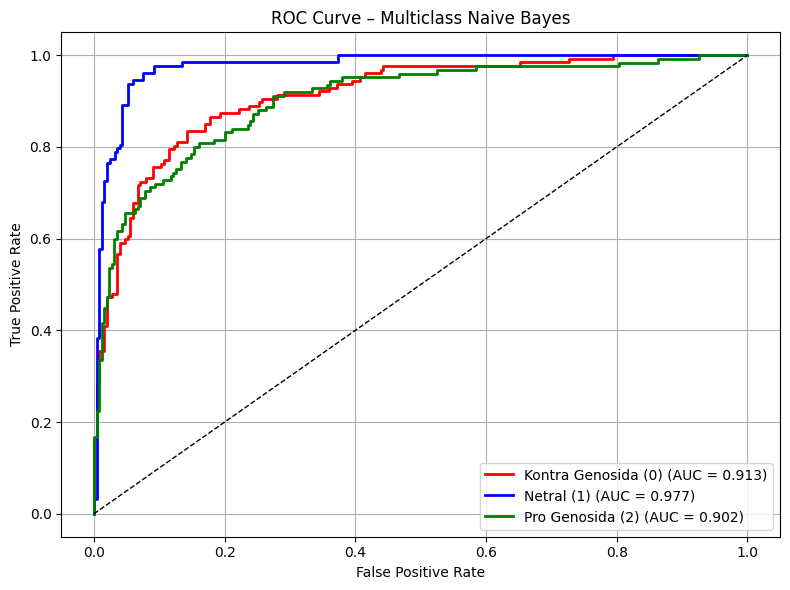

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)


# predict_proba wajib untuk ROC
y_proba = nb_final.predict_proba(X_test_tfidf)

# Hitung ROC per kelas
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

# Plot ROC
plt.figure(figsize=(8, 6))

colors = ["red", "blue", "green"]
labels = ["Kontra Genosida (0)", "Netral (1)", "Pro Genosida (2)"]

for i, c in enumerate(classes):
    plt.plot(fpr[c], tpr[c], lw=2, color=colors[i],
             label=f"{labels[i]} (AUC = {roc_auc[c]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)  # garis random guess

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Multiclass Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


SVM

In [20]:
# cross validation + grid search

X_train, X_test, y_train, y_test = train_test_split(
    df["full_text_processed"].astype(str),
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("svm", SVC(probability=True))
])


param_grid_svm = {
    "tfidf__max_features": [4000],
    "tfidf__ngram_range": [(1,2)],
    "tfidf__norm": ["l1", "l2"],

    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", "auto"]
}


grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=10,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)

# Best params & score
print("\n=== Best Parameters ===")
print(grid_svm.best_params_)

print("\n=== Best CV F1-Macro Score ===")
print(grid_svm.best_score_)

# Final evaluation (test set)
best_model = grid_svm.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== Final Evaluation on Test Set ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-Macro:", f1_score(y_test, y_pred, average="macro"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 10 folds for each of 24 candidates, totalling 240 fits

=== Best Parameters ===
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2'}

=== Best CV F1-Macro Score ===
0.8442789306655303

=== Final Evaluation on Test Set ===
Accuracy: 0.8763157894736842
F1-Macro: 0.8741613397976304

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       127
           1       0.93      0.99      0.96       128
           2       0.88      0.78      0.83       125

    accuracy                           0.88       380
   macro avg       0.88      0.88      0.87       380
weighted avg       0.88      0.88      0.87       380



In [21]:
import pandas as pd

print("=== Best Parameters ===")
print(grid_svm.best_params_)

print("\n=== Best F1-Macro Score ===")
print(grid_svm.best_score_)

print("\n=== Full Results ===")

results = pd.DataFrame(grid_svm.cv_results_)

cols = [
    "params",
    "mean_test_score",
    "std_test_score",
    "mean_fit_time",
    "rank_test_score"
]

df_results = results[cols].sort_values(by="mean_test_score", ascending=False)

# Tampilkan semua
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

print(df_results)


=== Best Parameters ===
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2'}

=== Best F1-Macro Score ===
0.8442789306655303

=== Full Results ===
                                                                                                                                             params  \
11       {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2'}   
18      {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l1'}   
19      {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2'}   
10       {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l1'}   
13     {'svm

In [23]:
# best model performance

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []
fold = 1

for train_idx, val_idx in skf.split(df["full_text_processed"], df["label"]):

    X_train_cv = df["full_text_processed"].iloc[train_idx].astype(str)
    X_val_cv   = df["full_text_processed"].iloc[val_idx].astype(str)
    y_train_cv = df["label"].iloc[train_idx]
    y_val_cv   = df["label"].iloc[val_idx]

    # TF-IDF (best params)
    tfidf = TfidfVectorizer(
        max_features=4000,
        ngram_range=(1, 2),
        norm="l2"
    )

    X_train_tfidf = tfidf.fit_transform(X_train_cv)
    X_val_tfidf   = tfidf.transform(X_val_cv)

    # SVM (best params)
    svm = SVC(
        kernel="rbf",
        C=1,
        gamma="scale"
    )

    svm.fit(X_train_tfidf, y_train_cv)

    # Prediction
    y_pred_cv = svm.predict(X_val_tfidf)

    # Evaluation (convert to %)
    acc  = accuracy_score(y_val_cv, y_pred_cv) * 100
    prec = precision_score(y_val_cv, y_pred_cv, average="macro") * 100
    rec  = recall_score(y_val_cv, y_pred_cv, average="macro") * 100
    f1   = f1_score(y_val_cv, y_pred_cv, average="macro") * 100

    results.append({
        "Fold": fold,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec
    })

    fold += 1

# Convert to DataFrame
df_cv_results_svm = pd.DataFrame(results).round(2)

print("=== 10-Fold Cross Validation Results (SVM) ===")
print(df_cv_results_svm)

print("\n=== Rata-rata Performa ===")
print(df_cv_results_svm.mean(numeric_only=True).round(2))

=== 10-Fold Cross Validation Results (SVM) ===
   Fold  Accuracy  F1-Score  Precision  Recall
0     1     87.89     87.72      88.58   87.77
1     2     87.37     87.14      87.25   87.25
2     3     80.00     79.92      80.36   79.89
3     4     88.42     88.40      88.44   88.37
4     5     84.74     84.72      84.77   84.67
5     6     90.53     90.50      90.57   90.49
6     7     86.77     86.53      87.23   86.64
7     8     82.01     81.99      82.32   81.93
8     9     84.66     84.59      84.66   84.54
9    10     87.30     87.11      87.21   87.22

=== Rata-rata Performa ===
Fold          5.50
Accuracy     85.97
F1-Score     85.86
Precision    86.14
Recall       85.88
dtype: float64


In [25]:
# Split data
X_text = df["full_text_processed"].astype(str)
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# TF-IDF (best params from GridSearch)
tfidf_final = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1, 2),
    norm="l2"
)

X_train_tfidf = tfidf_final.fit_transform(X_train_text)
X_test_tfidf  = tfidf_final.transform(X_test_text)

# SVM (best params from GridSearch)
svm_final = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True
)

svm_final.fit(X_train_tfidf, y_train)

# Prediction
y_pred_test = svm_final.predict(X_test_tfidf)

print("\n=== Classification Report (SVM) ===")
print(classification_report(y_test, y_pred_test))



=== Classification Report (SVM) ===
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       127
           1       0.93      0.99      0.96       128
           2       0.88      0.78      0.83       125

    accuracy                           0.88       380
   macro avg       0.88      0.88      0.87       380
weighted avg       0.88      0.88      0.87       380



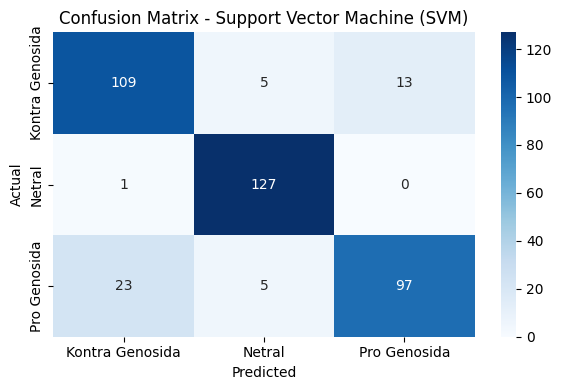

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Label kelas
class_labels = ["Kontra Genosida", "Netral", "Pro Genosida"]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix - Support Vector Machine (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


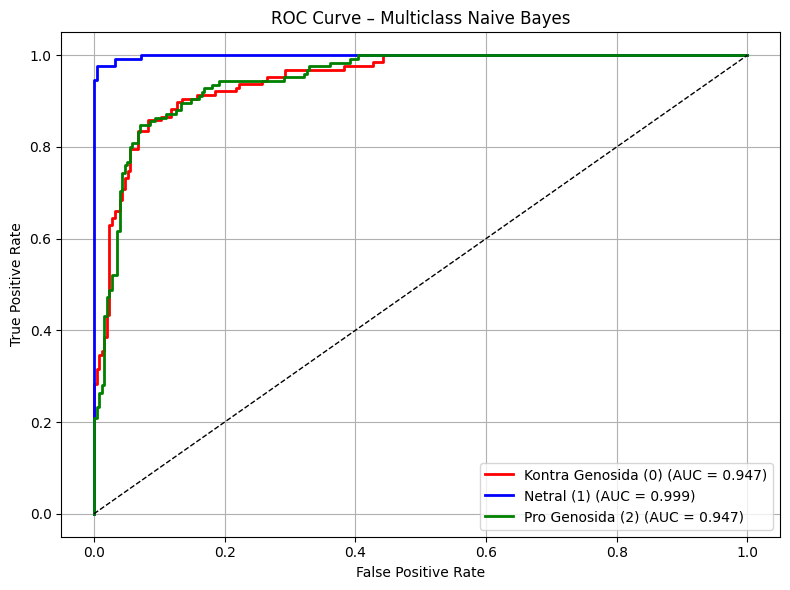

In [28]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

y_proba = svm_final.predict_proba(X_test_tfidf)

# Hitung ROC per kelas
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

# Plot ROC
plt.figure(figsize=(8, 6))

colors = ["red", "blue", "green"]
labels = ["Kontra Genosida (0)", "Netral (1)", "Pro Genosida (2)"]

for i, c in enumerate(classes):
    plt.plot(fpr[c], tpr[c], lw=2, color=colors[i],
             label=f"{labels[i]} (AUC = {roc_auc[c]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)  # garis random guess

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Multiclass Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
def predict_sentiment_nb(text, svm_final, vectorizer):
    text_vec = vectorizer.transform([text])

    pred_proba = svm_final.predict_proba(text_vec)[0]
    label = svm_final.predict(text_vec)[0]

    label_map = {
        0: "Kontra-Genocide",
        1: "Netral",
        2: "Pro-Genocide"
    }

    print(f"\nTeks: {text}")
    print(f"Prediksi: {label_map[label]} (label : {label})")
    print(f"Probabilitas: {pred_proba}")

    return label_map[label]


In [30]:
contoh_text = [
    "Israel is preventing humanitarian aid from entering Gaza, worsening the humanitarian crisis.",
    "Schools in Gaza have been destroyed, leaving young people already deprived of education due to COVID-19 and war, and facing a loss of future opportunities.",
    "Three Israeli hostages were handed over by Hamas in Gaza, while Palestinian prisoners were released as part of a ceasefire deal.",
    "A Chicago-based surgeon has treated patients with war-related injuries from Syria, Ukraine, and Gaza.",
    "Supporting Israel is described as supporting humanity, while opposing Hamas terrorism is also framed as a defense of human values.",
    "Hamas is the true terrorist."
]

for t in contoh_text:
    predict_sentiment_nb(t, svm_final, tfidf_final)


Teks: Israel is preventing humanitarian aid from entering Gaza, worsening the humanitarian crisis.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.96614488 0.00709409 0.02676104]

Teks: Schools in Gaza have been destroyed, leaving young people already deprived of education due to COVID-19 and war, and facing a loss of future opportunities.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.85634412 0.04202447 0.10163141]

Teks: Three Israeli hostages were handed over by Hamas in Gaza, while Palestinian prisoners were released as part of a ceasefire deal.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.77554999 0.08913427 0.13531573]

Teks: A Chicago-based surgeon has treated patients with war-related injuries from Syria, Ukraine, and Gaza.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.71126563 0.14268741 0.14604696]

Teks: Supporting Israel is described as supporting humanity, while opposing Hamas terrorism is also framed as a defense of human values.
Predik

SAVE MODEL

In [ ]:
joblib.dump(df["full_text_processed"].tolist(), "corpus.pkl")


['corpus.pkl']

In [ ]:
joblib.dump(X_train_tfidf, "/content/matrix.pkl")

['/content/matrix.pkl']

In [ ]:
joblib.dump(tfidf_final, "/content/vectorizer.pkl")
joblib.dump(nb_final, "/content/naive_bayes_model.pkl")
joblib.dump(svm_final, "/content/svm_model.pkl")

print("\n✅ Semua model & vectorizer berhasil disimpan:")
print("- vectorizer.pkl")
print("- naive_bayes_model.pkl")
print("- svm_model.pkl")


print("\nJumlah fitur TF-IDF:", len(tfidf_final.get_feature_names_out()))
print("NB expects features:", nb_final.n_features_in_)


✅ Semua model & vectorizer berhasil disimpan:
- vectorizer.pkl
- naive_bayes_model.pkl
- svm_model.pkl

Jumlah fitur TF-IDF: 4000
NB expects features: 4000


VISUALISASI TF_IDF


In [ ]:
# === 3. MENGAMBIL VOCAB TF-IDF ===
feature_names = vectorizer.get_feature_names_out()

# total bobot tiap kata (rata-rata)
tfidf_scores = np.asarray(X.mean(axis=0)).flatten()

# gabungkan fitur dan skor
tfidf_df = pd.DataFrame({
    "kata": feature_names,
    "bobot": tfidf_scores
})

# === 4. AMBIL 20 TF-IDF TERTINGGI ===
top20 = tfidf_df.sort_values(by="bobot", ascending=False).head(20)

print(top20)

# === 5. VISUALISASI BAR CHART ===
plt.figure(figsize=(12, 6))
plt.barh(top20["kata"][::-1], top20["bobot"][::-1])
plt.xlabel("Bobot TF-IDF")
plt.ylabel("Kata")
plt.title("20 Kata dengan Bobot TF-IDF Tertinggi")
plt.tight_layout()
plt.show()

In [ ]:
label_map = {
    2: "Pro Genosida",
    1: "Netral",
    0: "Kontra Genosida"
}

def plot_tfidf_by_label(df, label):
    subset = df[df["label"] == label]["full_text_processed"].astype(str)

    if subset.empty:
        print(f"Tidak ada data untuk label {label}")
        return

    vec = TfidfVectorizer(max_features=4000, ngram_range=(1,2))
    X = vec.fit_transform(subset)

    scores = np.asarray(X.mean(axis=0)).flatten()
    feat = vec.get_feature_names_out()

    tfidf_sub = pd.DataFrame({"kata": feat, "bobot": scores})
    top20 = tfidf_sub.sort_values(by="bobot", ascending=False).head(10)

    plt.figure(figsize=(10,5))
    plt.barh(top20["kata"][::-1], top20["bobot"][::-1])
    plt.title(f"10 TF-IDF Tertinggi - Kategori: {label_map[label]}")
    plt.xlabel("Bobot TF-IDF")
    plt.tight_layout()
    plt.show()


# panggil
plot_tfidf_by_label(df, 2)
plot_tfidf_by_label(df, 1)
plot_tfidf_by_label(df, 0)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# ambil data FINAL yang benar-benar dipakai
texts = (
    df["full_text_processed"]
    .dropna()
    .astype(str)
    .str.strip()
)

texts = texts[texts != ""]

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(texts)

# SAVE SEMUA DARI SUMBER YANG SAMA
joblib.dump(texts.tolist(), "corpus.pkl")
joblib.dump(X, "tfidf_matrix.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Jumlah corpus:", len(texts))
print("TF-IDF shape:", X.shape)


Jumlah corpus: 1896
TF-IDF shape: (1896, 4000)
